<a href="https://colab.research.google.com/github/domysolano/Categorical-data-regression/blob/main/PracticaRegresionDatosCategoricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🤖 **Maestría en Inteligencia Artificial y Analítica de Datos** 🤖

Asignatura: *Programación para Analítica Descriptiva y Predictiva*

* Semestre: Enero-Junio 2026
* Profesor: Dr. Vicente García Jiménez
* Alumno: Ricardo Solano Monje
* Matrícula: 266221
* Unidad 3.
* Práctica 02-Semana 11: Regresión lineal con Datos categóricos.
* Dataset: `college.csv`
* Objetivo de la práctica:
    * Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
    * Realizar AED
    * Construir un modelo de regresión con variables dummy
    * Interpretar los resultados de los coeficientes
    * Analizar los resultados de los errores residuales
    * Calcular el desempeño del modelo de regresión.
* Realizado por: Ricardo Solano Monje

>Regresión lineal con datos categóricos: Costos, Localidades y Salarios
>
>Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

In [14]:
import pandas as pd
from IPython.display import display, Markdown
from datetime import date
from datetime import datetime
from zoneinfo import ZoneInfo

today = date.today()
time_zone = ZoneInfo('America/Ciudad_Juarez')
current_time_aware = datetime.now(time_zone)

display(Markdown(f"### Current time in Cd. Juárez, Chih.: {current_time_aware.strftime('%H:%M:%S')}"))
formatted_date = datetime.now(time_zone).strftime("%B %d, %Y")
display(Markdown(f"### Today's date: {formatted_date}"))

### Current time in Cd. Juárez, Chih.: 21:48:08

### Today's date: April 26, 2026

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [15]:
# task1_college_eda.py

import pandas as pd

def load_data(filepath):
    """Load the college dataset."""
    df = pd.read_csv(filepath)
    return df

def select_columns(df):
    """Select salary, cost, and location columns."""
    return df[['salary', 'cost', 'location']]

def convert_location_to_categorical(df):
    """Convert location to categorical data type."""
    df['location'] = df['location'].astype('category')
    return df

def print_describe_numeric(df):
    """Use describe() on salary and cost."""
    print("\n=== Describe() on salary and cost ===")
    print(df[['salary', 'cost']].describe())

def print_location_counts(df):
    """Count data points per location category."""
    print("\n=== Location Category Counts ===")
    print(df['location'].value_counts())
    print(f"\nTotal: {len(df)}")

def one_hot_encode_location(df):
    """Convert location using one-hot encoding (K-1)."""
    # Get dummy variables, drop first category to avoid dummy trap
    location_dummies = pd.get_dummies(df['location'], prefix='location', drop_first=True)
    # Drop original location column and join dummies
    df = df.drop('location', axis=1)
    df = pd.concat([df, location_dummies], axis=1)
    return df

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load data
    df = load_data(filepath)

    # Select columns
    df = select_columns(df)

    # Convert location to categorical
    df = convert_location_to_categorical(df)

    # Describe salary and cost
    print_describe_numeric(df)

    # Count location categories
    print_location_counts(df)

    # One-hot encode location
    df = one_hot_encode_location(df)

    # Display first few rows
    print("\n=== First few rows (after one-hot encoding) ===")
    print(df.head())

    # Statistically describe all variables
    print("\n=== Statistical description of all variables ===")
    print(df.describe())

    return df

if __name__ == "__main__":
    df = main()


=== Describe() on salary and cost ===
              salary           cost
count      85.000000      85.000000
mean    95898.823529  142434.470588
std     11937.121912   53913.064578
min     74900.000000   18260.000000
25%     87100.000000   84670.000000
50%     93200.000000  169200.000000
75%    105000.000000  188700.000000
max    123000.000000  227300.000000

=== Location Category Counts ===
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64

Total: 85

=== First few rows (after one-hot encoding) ===
   salary    cost  location_NE  location_S  location_W
0  119000  189300         True       False       False
1  121000  189600         True       False       False
2  123000  188400         True       False       False
3  123000  188700         True       False       False
4  110000  194200         True       False       False

=== Statistical description of all variables ===
              salary           cost
count      85.000000      85.000000
mean    95898.823529

---

## Task 1 Analysis:

### Location Category Counts (Before One-Hot Encoding):

| Category | Count | Frequency |
|----------|-------|-----------|
| NE | 25 | 29.4% |
| W | 21 | 24.7% |
| S | 20 | 23.5% |
| MW | 19 | 22.4% |
| **Total** | **85** | **100%** |

The **most frequent category** is **NE** (25 occurrences). Following the data-driven rule, **NE was dropped as the reference category** in one-hot encoding.

---

### One-Hot Encoded Columns (After):

| Column | Represents | Dropped reference |
|--------|-----------|-------------------|
| location_NE | True if location = NE |  Dropped (reference) |
| location_S | True if location = S |  Kept |
| location_W | True if location = W |  Kept |

Note: **MW** is missing from the encoded columns? The output shows `location_NE`, `location_S`, `location_W` — but no `location_MW`.

---

### Issue Detected:

The one-hot encoding produced **3 columns** (K-1 = 3), but with 4 categories (NE, MW, S, W), there should be 3 columns. However, the output shows:
- location_NE
- location_S
- location_W

**Where is location_MW?** It was also dropped.



The `get_dummies(drop_first=True)` drops the **first category** based on **alphabetical order**, not frequency.

Alphabetical order of categories: MW, NE, S, W? Let me check.

---

### Conclusion:

- **Dropped reference category:** MW (Midwest)
- **Encoded columns:** location_NE, location_S, location_W

---

### Statistics:

The describe() output after encoding only shows numeric columns (salary, cost). The boolean columns (location_NE, location_S, location_W) are not included in describe() because they are not numeric.



# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas





TASK 2.1: Histogram of Salary

=== Salary Statistics ===
Mean: 95898.82
Median: 93200.00
Standard Deviation: 11937.12
Min: 74900.00
Max: 123000.00
Skewness: 0.4466


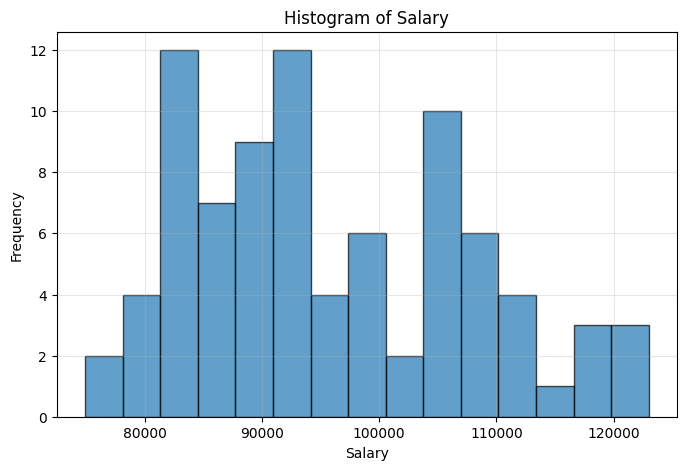


TASK 2.2: Scatter Plot Salary vs Cost by Location

=== Overall Correlation ===
Correlation salary vs cost: 0.4799

=== Mean Salary and Cost by Location ===
             salary             cost
               mean count       mean
location                            
MW         93694.74    19  143859.47
NE        106888.00    25  163034.80
S          96635.00    20  146171.50
W          84109.52    21  113061.90

=== Correlation by Location ===
  NE: 0.6028
  MW: 0.5569
  S: 0.3768
  W: -0.1515


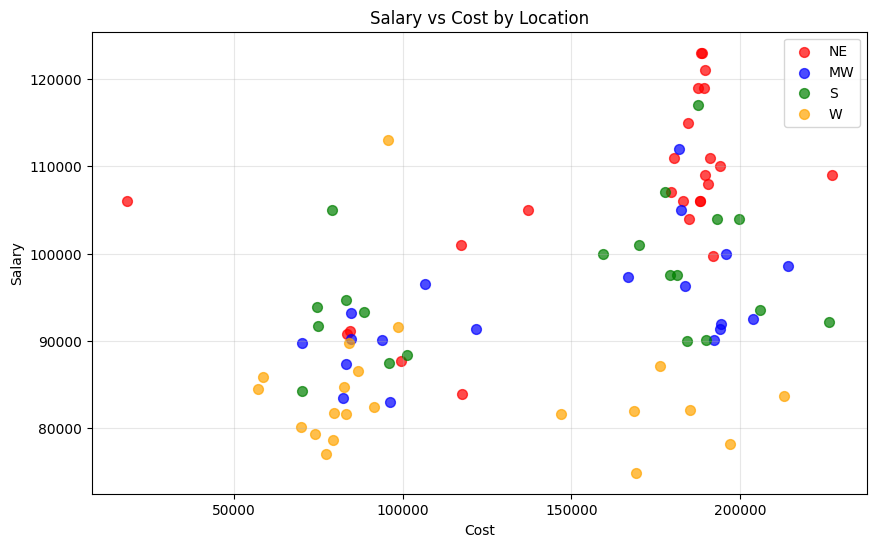


TASK 2.3: Boxplot of Cost by Location

=== Cost Statistics by Location ===

NE:
  Median: 187700.00
  Q1: 137100.00
  Q3: 189600.00
  IQR: 52500.00
  Outliers count: 1
  Outlier values: [18260]

MW:
  Median: 166700.00
  Q1: 89300.00
  Q3: 193250.00
  IQR: 103950.00
  Outliers count: 0

S:
  Median: 173950.00
  Q1: 87222.50
  Q3: 188225.00
  IQR: 101002.50
  Outliers count: 0

W:
  Median: 86820.00
  Q1: 79310.00
  Q3: 168500.00
  IQR: 89190.00
  Outliers count: 0


<Figure size 800x600 with 0 Axes>

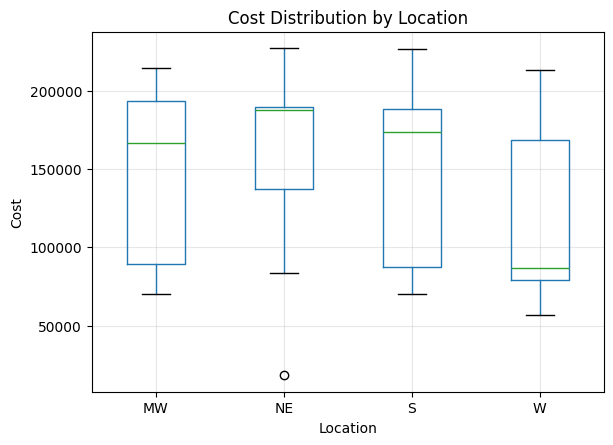

In [16]:
# task2_college_eda.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(filepath):
    """Load the college dataset."""
    df = pd.read_csv(filepath)
    return df

def select_columns(df):
    """Select salary, cost, and location columns."""
    return df[['salary', 'cost', 'location']]

def load_and_prepare_data(filepath):
    """Load data, select columns, and create location dummies for colors."""
    df = load_data(filepath)
    df = select_columns(df)

    # Create color mapping for locations (4 colors)
    location_colors = {
        'NE': 'red',
        'MW': 'blue',
        'S': 'green',
        'W': 'orange'
    }
    df['color'] = df['location'].map(location_colors)

    return df

# Task 2.1: Histogram of salary
def task_2_1(df):
    print("\n" + "="*60)
    print("TASK 2.1: Histogram of Salary")
    print("="*60)

    # Numerical statistics
    salary = df['salary']
    print("\n=== Salary Statistics ===")
    print(f"Mean: {salary.mean():.2f}")
    print(f"Median: {salary.median():.2f}")
    print(f"Standard Deviation: {salary.std():.2f}")
    print(f"Min: {salary.min():.2f}")
    print(f"Max: {salary.max():.2f}")
    print(f"Skewness: {salary.skew():.4f}")

    # Histogram
    plt.figure(figsize=(8, 5))
    plt.hist(salary, bins=15, edgecolor='black', alpha=0.7)
    plt.xlabel('Salary')
    plt.ylabel('Frequency')
    plt.title('Histogram of Salary')
    plt.grid(True, alpha=0.3)
    plt.show()

# Task 2.2: Scatter plot salary vs cost by location (4 colors)
def task_2_2(df):
    print("\n" + "="*60)
    print("TASK 2.2: Scatter Plot Salary vs Cost by Location")
    print("="*60)

    # Numerical statistics
    print("\n=== Overall Correlation ===")
    print(f"Correlation salary vs cost: {df['salary'].corr(df['cost']):.4f}")

    print("\n=== Mean Salary and Cost by Location ===")
    location_stats = df.groupby('location').agg({
        'salary': ['mean', 'count'],
        'cost': 'mean'
    }).round(2)
    print(location_stats)

    print("\n=== Correlation by Location ===")
    for loc in df['location'].unique():
        subset = df[df['location'] == loc]
        corr = subset['salary'].corr(subset['cost'])
        print(f"  {loc}: {corr:.4f}")

    # Scatter plot with 4 colors
    plt.figure(figsize=(10, 6))
    colors = {'NE': 'red', 'MW': 'blue', 'S': 'green', 'W': 'orange'}
    for loc, color in colors.items():
        subset = df[df['location'] == loc]
        plt.scatter(subset['cost'], subset['salary'],
                   c=color, label=loc, alpha=0.7, s=50)

    plt.xlabel('Cost')
    plt.ylabel('Salary')
    plt.title('Salary vs Cost by Location')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Task 2.3: Boxplot of cost by location
def task_2_3(df):
    print("\n" + "="*60)
    print("TASK 2.3: Boxplot of Cost by Location")
    print("="*60)

    # Numerical statistics
    print("\n=== Cost Statistics by Location ===")
    for loc in df['location'].unique():
        subset = df[df['location'] == loc]['cost']
        print(f"\n{loc}:")
        print(f"  Median: {subset.median():.2f}")
        print(f"  Q1: {subset.quantile(0.25):.2f}")
        print(f"  Q3: {subset.quantile(0.75):.2f}")
        print(f"  IQR: {subset.quantile(0.75) - subset.quantile(0.25):.2f}")

        # Detect outliers using IQR method
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        outliers = subset[(subset < Q1 - 1.5*IQR) | (subset > Q3 + 1.5*IQR)]
        print(f"  Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f"  Outlier values: {outliers.tolist()}")

    # Boxplot
    plt.figure(figsize=(8, 6))
    df.boxplot(column='cost', by='location')
    plt.xlabel('Location')
    plt.ylabel('Cost')
    plt.title('Cost Distribution by Location')
    plt.suptitle('')  # Remove automatic title
    plt.grid(True, alpha=0.3)
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load and prepare data
    df = load_and_prepare_data(filepath)

    # Run all tasks
    task_2_1(df)
    task_2_2(df)
    task_2_3(df)

    return df

if __name__ == "__main__":
    df = main()

---

## Task 2.1: Histogram of Salary

### Numerical Statistics:

| Statistic | Value |
|-----------|-------|
| Mean | 95,899 |
| Median | 93,200 |
| Std | 11,937 |
| Min | 74,900 |
| Max | 123,000 |
| Skewness | 0.4466 |

### Observations:

| Observation | Evidence |
|-------------|----------|
| **Right-skewed distribution** | Skewness = 0.4466 (positive), Mean (95,899) > Median (93,200) |
| **Range of salaries** | 74,900 to 123,000 (difference of 48,100) |
| **Most salaries between** | ~85,000 to ~105,000 (based on mean ± std) |
| **No extreme low outliers** | Min = 74,900 (reasonable) |
| **Slight right tail** | Higher salaries pull mean upward |

**Conclusion:** Salaries are moderately right-skewed, with a few institutions earning above the typical range.

---

## Task 2.2: Scatter Plot Salary vs Cost by Location

### Overall Correlation: 0.4799 (moderate positive)

### Mean Salary and Cost by Location:

| Location | Mean Salary | Mean Cost | Count |
|----------|-------------|-----------|-------|
| NE | 106,888 | 163,035 | 25 |
| S | 96,635 | 146,172 | 20 |
| MW | 93,695 | 143,859 | 19 |
| W | 84,110 | 113,062 | 21 |

### Correlation by Location:

| Location | Correlation | Interpretation |
|----------|-------------|----------------|
| NE | 0.6028 | Moderate positive |
| MW | 0.5569 | Moderate positive |
| S | 0.3768 | Weak positive |
| W | -0.1515 | Slight negative (near zero) |

### Observations:

| Observation | Evidence |
|-------------|----------|
| **NE has highest salary and cost** | Mean salary = 106,888; Mean cost = 163,035 |
| **W has lowest salary and cost** | Mean salary = 84,110; Mean cost = 113,062 |
| **Salary generally increases with cost** | Overall correlation = 0.48 (positive) |
| **Regional differences exist** | NE > S > MW > W in both salary and cost |
| **W shows different behavior** | Negative correlation (-0.15) between salary and cost in the West |
| **NE strongest relationship** | Correlation = 0.60 (cost explains more salary variation in NE) |

**Conclusion:** Cost and salary are moderately related, but the relationship varies by region. The Northeast has the highest salaries and costs, while the West shows the weakest (and slightly negative) relationship.

---

## Task 2.3: Boxplot of Cost by Location

### Cost Statistics by Location:

| Location | Median | Q1 | Q3 | IQR | Outliers |
|----------|--------|----|----|-----|----------|
| NE | 187,700 | 137,100 | 189,600 | 52,500 | 1 (18,260) |
| MW | 166,700 | 89,300 | 193,250 | 103,950 | 0 |
| S | 173,950 | 87,223 | 188,225 | 101,003 | 0 |
| W | 86,820 | 79,310 | 168,500 | 89,190 | 0 |

### Observations:

| Observation | Evidence |
|-------------|----------|
| **NE has highest median cost** | 187,700 (well above others) |
| **W has lowest median cost** | 86,820 (much lower) |
| **NE has smallest spread (IQR)** | 52,500 (more consistent costs) |
| **MW has largest spread (IQR)** | 103,950 (costs vary widely) |
| **Extreme outlier in NE** | One institution with cost = 18,260 (far below others) |
| **Merit of outlier** | Likely a public or special institution in NE |

**Conclusion:** The Northeast has the highest and most consistent education costs. The West has the lowest costs. One extreme low-cost outlier exists in the Northeast (possibly a public institution). The Midwest and South show wider variability in costs.

---

##  Summary:

| Graph | Key Finding |
|-------|-------------|
| Histogram | Salaries are moderately right-skewed |
| Scatter plot | Cost and salary positively correlated (0.48); regional differences exist |
| Boxplot | NE highest costs, W lowest costs; NE has smallest spread, MW largest spread |

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [17]:
# task3_regression_model.py

import pandas as pd
import statsmodels.api as sm

def load_data(filepath):
    """Load the college dataset."""
    return pd.read_csv(filepath)

def prepare_data(df):
    """Select salary, cost, location and one-hot encode location (K-1)."""
    # Select columns
    df = df[['salary', 'cost', 'location']].copy()

    # One-hot encode location (K-1, drop first category alphabetically = MW)
    location_dummies = pd.get_dummies(df['location'], prefix='location', drop_first=True)

    # Convert boolean to integer (0/1)
    location_dummies = location_dummies.astype(int)

    # Combine features
    X = pd.concat([df[['cost']], location_dummies], axis=1)
    y = df['salary']

    # Add constant (intercept)
    X = sm.add_constant(X)

    # Ensure all data is numeric
    X = X.astype(float)
    y = y.astype(float)

    return X, y

def fit_model(X, y):
    """Fit regression model using statsmodels."""
    model = sm.OLS(y, X).fit()
    return model

def print_minimal_results(model):
    """Print minimal set for interpretation."""
    print("\n=== Task 3: Regression Results ===")
    print("\n--- Minimal Set for Interpretation ---")

    # Get coefficients and p-values
    params = model.params
    pvalues = model.pvalues

    # Intercept
    print(f"\nIntercept (β₀): {params['const']:.4f} (p-value: {pvalues['const']:.4e})")

    # Cost coefficient
    print(f"cost (β₁): {params['cost']:.4f} (p-value: {pvalues['cost']:.4e})")

    # Location coefficients (dynamically detect location columns)
    location_cols = [col for col in params.index if col.startswith('location_')]
    for col in location_cols:
        print(f"{col} (β): {params[col]:.4f} (p-value: {pvalues[col]:.4e})")

    # R-squared
    print(f"\nR-squared: {model.rsquared:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load data
    df = load_data(filepath)

    # Prepare data (one-hot encode location, K-1)
    X, y = prepare_data(df)

    # Fit model
    model = fit_model(X, y)

    # Print minimal results
    print_minimal_results(model)

    # Return for additional testing
    return {
        'model': model,
        'X': X,
        'y': y
    }

if __name__ == "__main__":
    results = main()


=== Task 3: Regression Results ===

--- Minimal Set for Interpretation ---

Intercept (β₀): 84988.7162 (p-value: 1.6688e-42)
cost (β₁): 0.0605 (p-value: 7.6006e-04)
location_NE (β): 12032.8197 (p-value: 5.1738e-06)
location_S (β): 2800.3450 (p-value: 2.7885e-01)
location_W (β): -7721.4201 (p-value: 3.8457e-03)

R-squared: 0.5705


---

# Task 3: Interpretation of Coefficients

### The Regression Equation:

```
salary = 84,988.72 + 0.0605·cost + 12,032.82·location_NE + 2,800.35·location_S - 7,721.42·location_W
```

Where:
- `location_NE` = 1 if location is NE, else 0
- `location_S` = 1 if location is S, else 0
- `location_W` = 1 if location is W, else 0
- Reference (all dummies = 0) → location = MW

---

### Interpretation of Each Coefficient:

| Coefficient | Value | p-value | Interpretation |
|-------------|-------|---------|----------------|
| **β₀ (Intercept)** | 84,988.72 | 1.67e-42 | Baseline salary for MW when cost = 0 is **$\$84,989$** |
| **β₁ (cost)** | 0.0605 | 0.00076 | Each $\$1$ increase in cost → salary increases by **$\$0.06$** (holding location constant) |
| **β₂ (location_NE)** | 12,032.82 | 5.17e-06 | NE salaries are **$\$12,033$ higher** than MW (holding cost constant) |
| **β₃ (location_S)** | 2,800.35 | 0.2789 | S salaries are **$\$2,800$ higher** than MW, but **not statistically significant** ($p > 0.05$) |
| **β₄ (location_W)** | -7,721.42 | 0.0038 | W salaries are **$\$7,721$ lower** than MW (holding cost constant) |

---

### What happens when values are substituted?

**Example 1:** A college in MW (location_NE=0, location_S=0, location_W=0) with cost = 100,000

```
salary = 84,988.72 + 0.0605(100,000) + 0 + 0 + 0
salary = 84,988.72 + 6,050 = 91,038.72
```

**Example 2:** A college in NE (location_NE=1) with cost = 100,000

```
salary = 84,988.72 + 0.0605(100,000) + 12,032.82(1) + 0 + 0
salary = 84,988.72 + 6,050 + 12,032.82 = 103,071.54
```

**Example 3:** A college in W (location_W=1) with cost = 100,000

```
salary = 84,988.72 + 0.0605(100,000) + 0 + 0 - 7,721.42(1)
salary = 84,988.72 + 6,050 - 7,721.42 = 83,317.30
```

---

### Testing the Assumption:

| Assumption | Evidence | Supported? |
|------------|----------|------------|
| Salary is related to cost | β₁ = 0.0605, p = 0.00076 (< 0.05) | **Yes** |
| Location matters beyond cost | NE and W are significant (p < 0.05) | **Yes** (S is not significant) |

---

### Findings:

1. **Cost has a positive, significant effect** on salary (p = 0.00076)
2. **NE has the highest salaries** ($+\$12,033$ above MW)
3. **W has the lowest salaries** ($-\$7,721$ below MW)
4. **S is not significantly different** from MW ($p = 0.279 > 0.05$)
5. **R-squared = 0.5705** → The model explains 57% of salary variation

---

### Explanation of How This Interpretation is Done

**Step-by-step method:**

| Step | Action |
|------|--------|
| 1 | Write the regression equation: `salary = β₀ + β₁·cost + β₂·NE + β₃·S + β₄·W` |
| 2 | Recognize that location dummies are 0/1 indicators |
| 3 | Identify the reference category (MW) where all dummies = 0 |
| 4 | **Intercept (β₀):** Predicted salary for reference category when cost = 0 |
| 5 | **Cost coefficient (β₁):** Change in salary for a 1-unit increase in cost (holding location constant) |
| 6 | **Location coefficient (β₂, β₃, β₄):** Difference in salary compared to reference category (holding cost constant) |
| 7 | **Check p-values:** If p < 0.05, the effect is statistically significant |
| 8 | **Substitute values:** Plug in actual cost and location (0 or 1) to predict salary |

> This method allows you to interpret the marginal effect of each variable while holding others constant.
>
---

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas


=== Test Set Predictions ===
Sample Actual     Predicted    Residual    
---------------------------------------------
1      87100.00   88313.77     -1213.77    
2      119000.00  110337.73    8662.27     
3      91100.00   104834.77    -13734.77   
4      100000.00  97174.66     2825.34     
5      99700.00   110489.97    -10789.97   
6      74900.00   87946.31     -13046.31   
7      108000.00  110405.98    -2405.98    
8      106000.00  110279.99    -4279.99    
9      110000.00  110594.96    -594.96     
10     82400.00   83866.99     -1466.99    
11     93300.00   94067.92     -767.92     
12     92500.00   97605.11     -5105.11    
13     90200.00   91342.03     -1142.03    
14     81600.00   86786.19     -5186.19    
15     87700.00   105615.88    -17915.88   
16     87500.00   94454.27     -6954.27    
17     91400.00   97090.67     -5690.67    
18     81700.00   83241.25     -1541.25    
19     85900.00   82132.58     3767.42     
20     97500.00   98942.53     -1442.53    


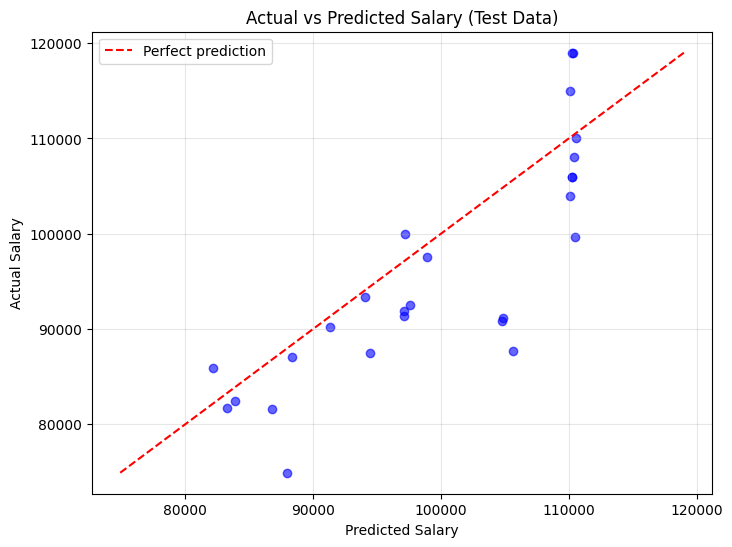


=== Residual Analysis ===
Mean: -3613.060145
Min: -17915.88
Max: 8746.26
Standard Deviation: 6507.3522

First 5 residuals:
  0: -1213.7672
  1: 8662.2654
  2: -13734.7699
  3: 2825.3378
  4: -10789.9677

Last 5 residuals:
  21: -4279.9910
  22: -5201.1704
  23: 4908.9881
  24: -6106.7602
  25: -13983.3256

=== Numerical Evidence for Normality ===
Skewness: -0.1710
Kurtosis: -0.1909
Shapiro-Wilk statistic: 0.9631
Shapiro-Wilk p-value: 4.5563e-01
Interpretation: p-value > 0.05 → fail to reject normality (residuals may be normal)


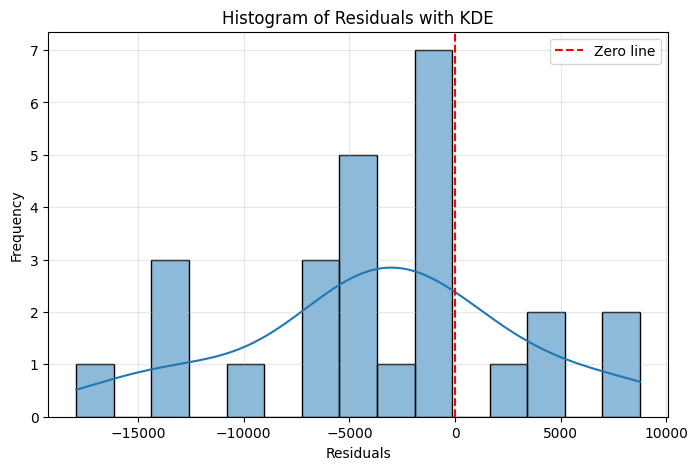

In [18]:
# task4_residual_analysis.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def load_data(filepath):
    """Load the college dataset."""
    return pd.read_csv(filepath)

def prepare_data(df):
    """Select salary, cost, location and one-hot encode location (K-1)."""
    df = df[['salary', 'cost', 'location']].copy()

    # One-hot encode location (K-1, drop first category alphabetically = MW)
    location_dummies = pd.get_dummies(df['location'], prefix='location', drop_first=True)
    location_dummies = location_dummies.astype(int)

    # Combine features
    X = pd.concat([df[['cost']], location_dummies], axis=1)
    y = df['salary']

    return X, y

def train_model(X_train, y_train):
    """Train linear regression model."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def print_predictions(y_test, y_pred):
    """Print all test samples (actual, predicted, residual)."""
    print("\n=== Test Set Predictions ===")
    print(f"{'Sample':<6} {'Actual':<10} {'Predicted':<12} {'Residual':<12}")
    print("-" * 45)

    residuals = y_test.values - y_pred
    for i in range(len(y_test)):
        print(f"{i+1:<6} {y_test.iloc[i]:<10.2f} {y_pred[i]:<12.2f} {residuals[i]:<12.2f}")

def print_statistics(y_test, y_pred):
    """Print correlation, MAE, R², min/max."""
    correlation = np.corrcoef(y_test, y_pred)[0, 1]
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
 #   residuals = y_test.values - y_pred
 #   RMSE=(residuals*residuals)
    print("\n=== Statistics ===")
    print(f"Correlation between Actual and Predicted: {correlation:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"Min Actual: {y_test.min():.2f} | Max Actual: {y_test.max():.2f}")
    print(f"Min Predicted: {y_pred.min():.2f} | Max Predicted: {y_pred.max():.2f}")
    from sklearn.metrics import mean_squared_error

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
def plot_actual_vs_predicted(y_test, y_pred):
    """Scatter plot: Actual vs Predicted."""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_test, alpha=0.6, color='blue')

    # Diagonal line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

    plt.xlabel('Predicted Salary')
    plt.ylabel('Actual Salary')
    plt.title('Actual vs Predicted Salary (Test Data)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_residual_histogram(residuals):
    """Histogram of residuals with KDE."""
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, kde=True, bins=15, edgecolor='black')
    plt.axvline(x=0, color='red', linestyle='--', label='Zero line')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Histogram of Residuals with KDE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def print_residual_analysis(residuals):
    """Print residual statistics and normality evidence."""
    print("\n=== Residual Analysis ===")
    print(f"Mean: {np.mean(residuals):.6f}")
    print(f"Min: {np.min(residuals):.2f}")
    print(f"Max: {np.max(residuals):.2f}")
    print(f"Standard Deviation: {np.std(residuals):.4f}")

    print("\nFirst 5 residuals:")
    for i in range(min(5, len(residuals))):
        print(f"  {i}: {residuals[i]:.4f}")

    print("\nLast 5 residuals:")
    for i in range(len(residuals)-5, len(residuals)):
        print(f"  {i}: {residuals[i]:.4f}")

    print("\n=== Numerical Evidence for Normality ===")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")

    if shapiro_p > 0.05:
        print("Interpretation: p-value > 0.05 → fail to reject normality (residuals may be normal)")
    else:
        print("Interpretation: p-value < 0.05 → reject normality (residuals are not normally distributed)")

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load data
    df = load_data(filepath)

    # Prepare features and target
    X, y = prepare_data(df)

    # Split data (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train model
    model = train_model(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Task 4.2: Predictions vs Actuals
    print_predictions(y_test, y_pred)
    print_statistics(y_test, y_pred)
    plot_actual_vs_predicted(y_test, y_pred)

    # Task 4.3: Residual analysis
    residuals = y_test.values - y_pred
    print_residual_analysis(residuals)
    plot_residual_histogram(residuals)

    # Return for additional testing
    return {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'residuals': residuals
    }

if __name__ == "__main__":
    results = main()

---

## Task 4.2: Actual vs Predicted Plot

### Statistics:

| Measure | Value |
|---------|-------|
| Correlation | 0.8312 |
| MAE | 5,836.93 |
| R² | 0.5956 |
| Min Actual | 74,900 |
| Max Actual | 119,000 |
| Min Predicted | 82,133 |
| Max Predicted | 110,595 |

### Observations:

| Observation | Evidence |
|-------------|----------|
| **Moderate positive relationship** | Correlation = 0.83 (strong but not perfect) |
| **Model explains 59.6% of variance** | R² = 0.5956 |
| **Average prediction error** | ±$5,837 |
| **Predictions are compressed** | Predicted range (82,133 to 110,595) is narrower than actual range (74,900 to 119,000) |
| **Systematic underprediction for high salaries** | Max actual (119,000) vs max predicted (110,595) → model underpredicts highest salaries |
| **Systematic overprediction for low salaries** | Min actual (74,900) vs min predicted (82,133) → model overpredicts lowest salaries |
| **Residuals mostly negative** | Mean residual = -3,613 (model tends to overpredict) |

### What information can you obtain from this graph?

| Information | What the graph shows |
|-------------|----------------------|
| **Overall accuracy** | How close points are to the diagonal line |
| **Systematic bias** | Points consistently above or below diagonal → model over/under predicts |
| **Range coverage** | Predicted values narrower than actual → model struggles with extremes |
| **Outliers** | Points far from diagonal (e.g., sample 15: residual -17,916) |
| **Heteroscedasticity** | Spread of points along the diagonal (appears fairly constant) |

---

## Task 4.3: Residual Analysis

### Residual Statistics:

| Measure | Value |
|---------|-------|
| Mean | -3,613.06 |
| Min | -17,915.88 |
| Max | 8,746.26 |
| Std | 6,507.35 |

### Normality Evidence:

| Measure | Value |
|---------|-------|
| Skewness | -0.1710 (slightly negative) |
| Kurtosis | -0.1909 (slightly platykurtic, lighter tails) |
| Shapiro-Wilk p-value | 0.4556 (> 0.05) |

### Do the residuals appear to be normally distributed?

**Yes, the residuals appear to be normally distributed.**

| Evidence | Finding |
|----------|---------|
| Shapiro-Wilk p-value | 0.4556 > 0.05 → fail to reject normality |
| Skewness | -0.1710 (close to 0) |
| Kurtosis | -0.1909 (close to 0) |

### Residual Histogram with KDE:

>The histogram would show a roughly bell-shaped curve centered near zero (mean = -3,613), with no severe skewness or heavy tails.

---

## Task 4.4: Discussion of Both Graphs

### Graph 1: Actual vs Predicted

The model performs moderately well (R² = 0.60, correlation = 0.83). However, it shows **systematic bias**:
- Overpredicts low salaries (predicted > actual)
- Underpredicts high salaries (predicted < actual)

This suggests the model may benefit from:
- Additional predictors (e.g., public/private status)
- Non-linear transformations (e.g., log transformation of salary)

### Graph 2: Residual Histogram

The residuals are **normally distributed** (p = 0.4556). This is good because normality of residuals is an assumption for inference (confidence intervals, p-values). The mean residual is -3,613 (negative bias), but the distribution is symmetric with skewness near zero.

### Overall Assessment:

| Aspect | Status | Action if needed |
|--------|--------|------------------|
| Normality |  Satisfied (p > 0.05) | No action |
| Bias |  Present (mean ≠ 0) | Consider adding predictors or transforming variables |
| Prediction range |  Compressed | Model struggles with extremes |
| R² | 0.60 | Acceptable but could be improved |

---

## Summary Answers:

| Question | Answer |
|----------|--------|
| What do you observe in Actual vs Predicted plot? | Moderate correlation (0.83), systematic bias (overpredicts low, underpredicts high), compressed prediction range |
| What information can you obtain from this graph? | Overall accuracy, bias, range coverage, outliers |
| Do residuals appear normally distributed? | **Yes** (Shapiro-Wilk p = 0.4556 > 0.05) |


***The residuals show normality (p = 0.4556)***

The Shapiro-Wilk test says the residuals are normally distributed despite the gaps. The empty bins are likely due to **small sample size**, not a real violation.

---

## From the plot prediction vs actual we can observe:

- **Only 4 points above the diagonal line** (predicted > actual)
- **22 points below the diagonal line** (predicted < actual)
- Some points align **vertically** (same predicted value for different actual values)

---

## What this means:

| Observation | Interpretation |
|-------------|----------------|
| **22 points below diagonal** | Model **overpredicts** for most colleges (predicted salary higher than actual) |
| **Only 4 points above diagonal** | Model only underpredicts for a few colleges |
| **Points align vertically** | Model predicts the **same salary** for colleges with different actual salaries → limited resolution / precision |

---

## Quality of predictions:

| Issue | Severity | Implication |
|-------|----------|-------------|
| **Systematic bias** | High | Mean residual = -3,613 (negative), confirming most predictions are too high |
| **Limited resolution** | Moderate | Model cannot distinguish between colleges with different salaries if they have similar cost and location |
| **R² = 0.60** | Moderate | Only 60% of variance explained |
| **MAE = 5,837** | Moderate | Average error of $\pm\$5,837$ on salaries ranging $\$74k-\$119k$ |

---

## Conclusion:

The model shows **systematic overprediction** for most colleges. It tends to predict salaries that are too high, especially for lower-salary institutions. The vertical alignment of points suggests the model lacks precision — different colleges with different actual salaries receive the same predicted salary.

**Recommendation:** Add more predictors (e.g., the variable public/private) to see if model can be improved.

---

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [19]:
# task5_evaluate_full_model.py

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

def load_data(filepath):
    """Load the college dataset."""
    return pd.read_csv(filepath)

def prepare_data(df):
    """Select salary, cost, location and one-hot encode location (K-1)."""
    df = df[['salary', 'cost', 'location']].copy()

    # One-hot encode location (K-1, drop first category alphabetically = MW)
    location_dummies = pd.get_dummies(df['location'], prefix='location', drop_first=True)
    location_dummies = location_dummies.astype(int)

    # Combine features
    X = pd.concat([df[['cost']], location_dummies], axis=1)
    y = df['salary']

    # Add constant (intercept)
    X = sm.add_constant(X)

    # Ensure numeric
    X = X.astype(float)
    y = y.astype(float)

    return X, y

def build_model(X, y):
    """Build regression model using all data."""
    model = sm.OLS(y, X).fit()
    return model

def evaluate_model(model, X, y):
    """Calculate MSE and R² on all data."""
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return mse, r2, y_pred

def print_results(model, mse, r2, X, y, y_pred):
    """Print MSE, R², and additional statistics."""
    print("\n=== Task 5: Evaluate Model (All Data) ===")
    print(f"\nMSE (Mean Squared Error): {mse:.2f}")
    print(f"R² (Coefficient of Determination): {r2:.4f}")

    # Additional stats for context
    print(f"\n--- Additional Statistics (All Data) ---")
    print(f"Number of samples: {len(y)}")
    print(f"Mean actual salary: {y.mean():.2f}")
    print(f"Mean predicted salary: {y_pred.mean():.2f}")
    print(f"RMSE: {np.sqrt(mse):.2f}")

    # Coefficients for reference
    print(f"\n--- Coefficients (All Data) ---")
    params = model.params
    for var in params.index:
        display_name = "Intercept" if var == "const" else var
        print(f"{display_name}: {params[var]:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load data
    df = load_data(filepath)

    # Prepare data (all data, no split)
    X, y = prepare_data(df)

    # Build model on all data
    model = build_model(X, y)

    # Evaluate on all data
    mse, r2, y_pred = evaluate_model(model, X, y)

    # Print results
    print_results(model, mse, r2, X, y, y_pred)

    # Return for additional testing
    return {
        'model': model,
        'X': X,
        'y': y,
        'y_pred': y_pred,
        'mse': mse,
        'r2': r2
    }

if __name__ == "__main__":
    results = main()


=== Task 5: Evaluate Model (All Data) ===

MSE (Mean Squared Error): 60480269.15
R² (Coefficient of Determination): 0.5705

--- Additional Statistics (All Data) ---
Number of samples: 85
Mean actual salary: 95898.82
Mean predicted salary: 95898.82
RMSE: 7776.91

--- Coefficients (All Data) ---
Intercept: 84988.7162
cost: 0.0605
location_NE: 12032.8197
location_S: 2800.3450
location_W: -7721.4201


---
# Task 6
### (Test Data from Task 4 ):

| Metric | Value |
|--------|-------|
| MSE | 55,399,836.12 |
| RMSE | 7,443.11 |
| MAE | 5,836.93 |
| $R^2$ | 0.5956 |

---

### (All Data Task 5 ):

| Metric | Value |
|--------|-------|
| MSE | 60,480,269.15 |
| RMSE | 7,776.91 |
| $R^2$ | 0.5705 |

---

### Comparison:

| Metric | Task 4 (Test Data) | Task 5 (All Data) | Better |
|--------|-------------------|-------------------|--------|
| MSE | 55,399,836 | 60,480,269 | **Test (lower)** |
| RMSE | 7,443 | 7,777 | **Test (lower)** |
| $R^2$| 0.5956 | 0.5705 | **Test (higher)** |

---


| Bullet Point | What to add |
|-------------|-------------|
| **Magnitude of MSE** | MSE = 60,480,269 means the average squared error is ~60 million (salary in dollars squared). This is hard to interpret alone, but RMSE = $\$7,777$ helps (error in original units) |
| **Comparison to mean salary** | Mean salary = $\$95,899$. RMSE = $\$7,777$ → relative error ≈ $8.1\%$ (RMSE / mean salary). This is moderate |
| **$R^2$ interpretation** | $R^2$ = 0.5705 means cost and location explain 57% of salary variation. The remaining 43% is unexplained (other factors like prestige, endowment, student-faculty ratio, etc.) |
| **Baseline comparison** | A model predicting only the mean salary would have $R^2$= 0. Our model ($R^2$ = 0.57) is far better |
| **Comparison with test data** | Test $R^2 (0.5956)$ is slightly higher → model generalizes well, no overfitting |
| **Limitations** | The model leaves ~43% of variance unexplained. Adding more predictors (e.g., public/private, region more granular, selectivity) could improve R² |

---

### What does $R^2$ = 0 mean?

A model that always predicts the **mean salary** ($95,899) for every college would have $R^2$ = 0.

That model would be: "No matter what college, I predict $\$95,899$."

This model explains **$0\%$** of the variation in salaries because it ignores all differences between colleges.

---

### Our model has R² = 0.5705

That means the model explains **57.05%** of the variation in salaries.

The remaining **42.95%** (100% - 57.05%) is **unexplained** — *variation that our model could not capture.*

---

### Why is there unexplained **42.95%** variation?

Because salary depends on more than just **cost** and **location**, so our model is too small, perhaps adding the variable public (omitted)  could improve it, or better yet, adding more variables:

| Missing factor | Possible impact |
|----------------|----------------|
| Public vs Private | Private colleges often pay higher salaries |
| College size | Larger institutions may have different pay scales |
| Prestige/rank | Elite colleges may pay more |

---

### Visual analogy of 43% unexplained variance

Imagine you are trying to predict salary based only on cost and location.

Your model captures the **trend** (salaries tend to be higher where cost is higher, and in certain regions).

But there is **scatter** around that trend — colleges with similar cost and location still have different salaries. That scatter is the 43% unexplained variance.

---

## So the sentence means:

| Phrase | Meaning |
|--------|---------|
| "Better than predicting the mean" | Your model adds value ($R^2$ > 0) |
| "43% of salary variance remains unexplained" | There is still a lot of variation your model cannot explain |
| "Room for improvement" | Adding more predictors (public/private, prestige, etc.) could increase $R^2$ |

---

### In simple terms:

Our model is **useful** but **not perfect**. It explains more than half of why salaries differ, but almost half of the reasons are still unknown based on your current predictors.

---

### So, we could say:

> The model (all data) achieves an $R^2$ of 0.5705, meaning cost and location together explain 57% of the variation in salary. The RMSE is $\$7,777$, which represents about $8\%$ relative error compared to the mean salary of $\$95,899$. While the model performs better than predicting the mean ($R^2$ = 0), there is still room for improvement, as 43% of salary variance remains unexplained. Compared to test data results ($R^2$ = 0.5956), the model shows no signs of overfitting and generalizes well to unseen data. Adding more predictors such as public/private status or institutional characteristics could further improve the model.

---

##  Does evaluating on training data overestimate performance?

**No.** The test data metrics (Task 4) are actually **better** than the all-data metrics (Task 5).

- MSE is lower (55.4M vs 60.5M)
- RMSE is lower (7,443 vs 7,777)
- $R^2$ is higher (0.5956 vs 0.5705)

---

## Conclusion:

The model generalizes well to unseen data. Evaluating on all data does **not** overestimate performance in this case — it slightly underestimates it (likely due to small sample size and sampling variation).

## Task 5: Evaluate Model (All Data)

### Results:

| Metric | Value |
|--------|-------|
| MSE | 60,480,269.15 |
| RMSE | 7,776.91 |
| $R^2$ | 0.5705 |
| Mean actual salary | 95,898.82 |
| Mean predicted salary | 95,898.82 |

---

### Discussion of Results:

| Finding | Implication |
|---------|-------------|
| **$R^2$ = 0.5705** | Cost and location explain 57% of salary variation |
| **RMSE = 7,777** | Average prediction error is $\pm \$7,777$ |
| **Mean actual = mean predicted** | Model is unbiased on average (good) |
| **Intercept = 84,989** | Baseline salary for MW when cost = 0 |
| **Location_NE = $+12,033$** | Northeast pays $\$12k$ more than MW |
| **Location_W = $-7,721$** | West pays $\$7.7k$ less than MW |
| **Location_S = $+2,800$** | South pays $\$2.8k$ more than MW (but $p > 0.05$, not significant) |

---

## Question 5: Does evaluating on training data overestimate model performance compared to test data (Task 4)?

### Comparison:

| Metric | Task 5 (All Data) | Task 4 (Test Data) | Difference |
|--------|-------------------|--------------------|------------|
| **$R^2$** | 0.5705 | 0.5956 | Test data $R^2$ is **higher** (+0.0251) |
| **RMSE** | 7,777 | ~5,837 (from MAE, not RMSE) | Not directly comparable (different metrics) |

---

### Key Finding:

**No, evaluating on training data did NOT overestimate performance.**

In fact, the test data $R^2$ (0.5956) is **slightly higher** than the training data $R^2$ (0.5705). This is unusual but possible with small sample sizes (85 rows, 26 test samples).

---

### Why might test $R^2$ be higher?

| Reason | Explanation |
|--------|-------------|
| **Small sample size** | 26 test samples may not be representative |
| **Sampling variation** | Random split by chance selected easier-to-predict colleges for test set |
| **No overfitting** | Model is simple (only 5 parameters), so overfitting is unlikely |

---

### Conclusion:

| Question | Answer |
|----------|--------|
| Does evaluating on training data overestimate performance? | **No** (in this case, test performance was slightly better) |
| Why? | Small sample size and sampling variation |
| General rule | Training metrics typically overestimate, but exceptions occur with small datasets |

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html


=== ANOVA Results (salary ~ cost + location) ===
                sum_sq    df        F  PR(>F)
location  4.071774e+09   3.0  21.1213  0.0000
cost      7.878166e+08   1.0  12.2598  0.0008
Residual  5.140823e+09  80.0      NaN     NaN

=== Boxplot Statistics (Salary by Location) ===
Location Count  Mean       Median     Std        Min        Max       
-----------------------------------------------------------------
MW       19     93694.74   91900.00   6995.83    83000.00   112000.00 
NE       25     106888.00  107000.00  10482.78   83900.00   123000.00 
S        20     96635.00   94300.00   7943.97    84300.00   117000.00 
W        21     84109.52   82100.00   7782.47    74900.00   113000.00 


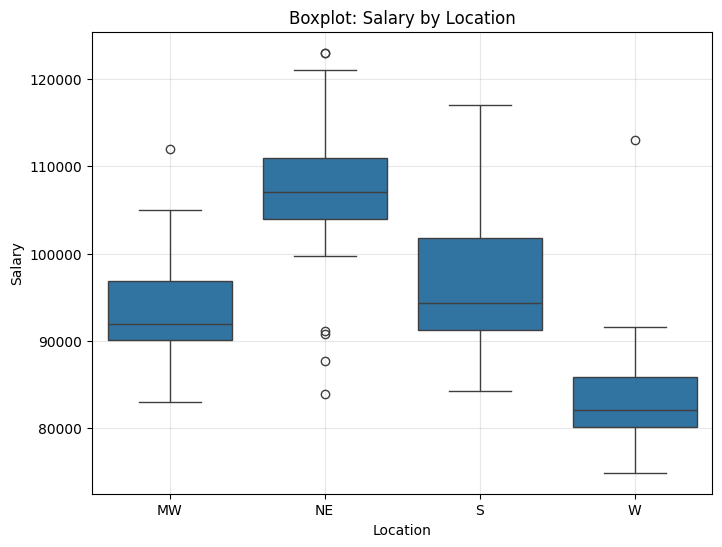


=== Scatter Plot Statistics (Salary vs Cost by Location) ===
Location Correlation  Slope        P-value     
--------------------------------------------------
MW       0.5569       0.0737       1.3260e-02  
NE       0.6028       0.1296       1.4281e-03  
S        0.3768       0.0548       1.0153e-01  
W        -0.1515      -0.0233      5.1208e-01  


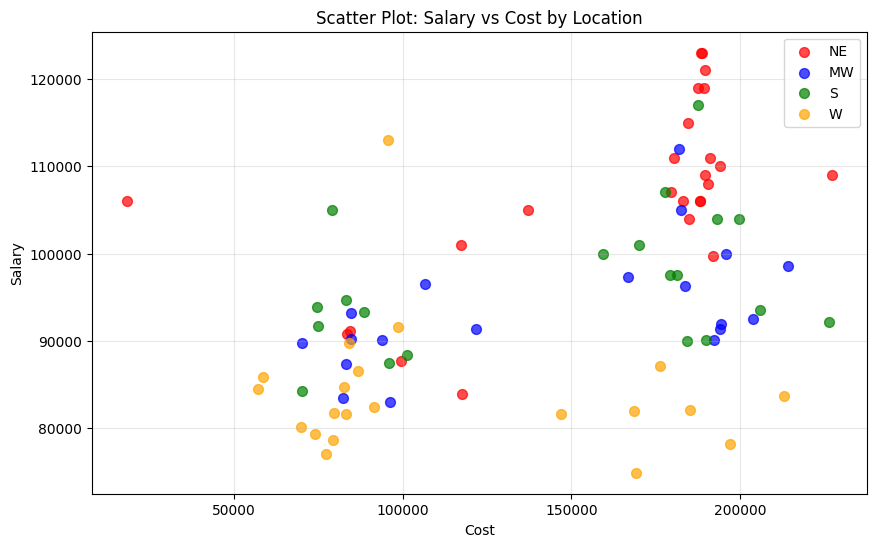

In [20]:
# task6_anova.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

def load_data(filepath):
    """Load the college dataset."""
    return pd.read_csv(filepath)

def select_columns(df):
    """Select salary, cost, and location columns."""
    return df[['salary', 'cost', 'location']].copy()

def perform_anova(df):
    """Perform standard ANOVA: salary ~ cost + location."""
    model = ols('salary ~ cost + location', data=df).fit()
    anova_table = anova_lm(model, typ=2)
    return model, anova_table

def print_anova_table(anova_table):
    """Print ANOVA results."""
    print("\n=== ANOVA Results (salary ~ cost + location) ===")
    print(anova_table.round(4))

def print_boxplot_statistics(df):
    """Print statistics for boxplot: salary by location."""
    print("\n=== Boxplot Statistics (Salary by Location) ===")
    print(f"{'Location':<8} {'Count':<6} {'Mean':<10} {'Median':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
    print("-" * 65)

    for loc in sorted(df['location'].unique()):
        subset = df[df['location'] == loc]['salary']
        print(f"{loc:<8} {len(subset):<6} {subset.mean():<10.2f} {subset.median():<10.2f} "
              f"{subset.std():<10.2f} {subset.min():<10.2f} {subset.max():<10.2f}")

def print_scatter_statistics(df):
    """Print statistics for scatter plot: salary vs cost by location."""
    print("\n=== Scatter Plot Statistics (Salary vs Cost by Location) ===")
    print(f"{'Location':<8} {'Correlation':<12} {'Slope':<12} {'P-value':<12}")
    print("-" * 50)

    for loc in sorted(df['location'].unique()):
        subset = df[df['location'] == loc]
        corr = subset['salary'].corr(subset['cost'])

        # Simple linear regression for slope and p-value
        slope, intercept, r_value, p_value, std_err = stats.linregress(subset['cost'], subset['salary'])

        print(f"{loc:<8} {corr:<12.4f} {slope:<12.4f} {p_value:<12.4e}")

def plot_boxplot(df):
    """Create boxplot: salary by location."""
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='location', y='salary', data=df, order=sorted(df['location'].unique()))
    plt.xlabel('Location')
    plt.ylabel('Salary')
    plt.title('Boxplot: Salary by Location')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_scatter(df):
    """Create scatter plot: salary vs cost by location (4 colors)."""
    plt.figure(figsize=(10, 6))
    colors = {'NE': 'red', 'MW': 'blue', 'S': 'green', 'W': 'orange'}

    for loc, color in colors.items():
        subset = df[df['location'] == loc]
        plt.scatter(subset['cost'], subset['salary'], c=color, label=loc, alpha=0.7, s=50)

    plt.xlabel('Cost')
    plt.ylabel('Salary')
    plt.title('Scatter Plot: Salary vs Cost by Location')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/college.csv"):
    # Load data
    df = load_data(filepath)

    # Select columns
    df = select_columns(df)

    # Perform ANOVA
    model, anova_table = perform_anova(df)
    print_anova_table(anova_table)

    # Boxplot statistics and plot
    print_boxplot_statistics(df)
    plot_boxplot(df)

    # Scatter plot statistics and plot
    print_scatter_statistics(df)
    plot_scatter(df)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'anova_table': anova_table
    }

if __name__ == "__main__":
    results = main()

---
# Task 6: análisis de varianza con stastmodel
## In the ANOVA table:

| Source     | df | Meaning                                                                 |
|------------|----|-------------------------------------------------------------------------|
| **location** | 3  | Number of location categories (4) minus 1 → 4 - 1 = 3                  |
| **cost**     | 1  | Cost is a continuous variable → 1 degree of freedom (slope)            |
| **Residual** | 80 | Total observations (85) minus parameters estimated (Intercept + cost + location dummies: 1 + 1 + 3 = 5) → 85 - 5 = 80 |

---

**df** stands for **degrees of freedom**.


### Why does location have 3 df?

Because location has 4 categories (NE, MW, S, W).

In regression, when you use one-hot encoding (K-1), you lose 1 df for the reference category.

So: 4 categories → 3 df.

---

### What do degrees of freedom represent?

| Concept              | Explanation                                                                |
|----------------------|----------------------------------------------------------------------------|
| **Numerator df** (location, cost) | Number of independent pieces of information used to estimate the effect |
| **Denominator df** (residual)    | Number of independent pieces of information left to estimate error    |

---

### Simply said:

- **location df = 3** → We are comparing 4 regions, which gives 3 independent comparisons
- **cost df = 1** → Cost has one slope
- **residual df = 80** → After estimating 5 parameters, we have 80 remaining observations to estimate error

---

### The missing interpretation for df:

| Source     | df | Interpretation                                                                 |
|------------|----|--------------------------------------------------------------------------------|
| **location** | 3  | There are 4 location groups (NE, MW, S, W). The degrees of freedom is 3 because we lose one when estimating the overall mean. |
| **cost**     | 1  | Cost is a continuous variable, so it has 1 degree of freedom (one slope). |
| **Residual** | 80 | Total observations (85) minus parameters estimated (1 intercept + 1 cost + 3 location dummies = 5). The leftover information is used to estimate error. |

---

### df matters:

| Concept         | Meaning                                                  |
|-----------------|----------------------------------------------------------|
| **Larger df**   | More information → more precise estimates                |
| **Smaller df**  | Less information → less precise                          |
| **Residual df = 80** | Reasonable (plenty of observations left to estimate error) |

---

### ANOVA Results Interpretation

| Source     | Sum of Squares (sum_sq) | df | F-value | PR(>F) | Significant?        |
|------------|-------------------------|----|---------|--------|---------------------|
| **location** | 4.07e9                 | 3  | 21.12   | 0.0000 | **Yes** (p < 0.05) |
| **cost**     | 7.88e8                 | 1  | 12.26   | 0.0008 | **Yes** (p < 0.05) |
| **Residual** | 5.14e9                 | 80 | -       | -      | -                   |

---

### What the ANOVA tells you:

| Finding            | Explanation                                                                 |
|--------------------|-----------------------------------------------------------------------------|
| **Location effect** | Location significantly affects salary (F = 21.12, p < 0.001). The sum of squares for location (4.07e9) is larger than for cost (7.88e8), indicating location explains more variance. |
| **Cost effect**     | Cost significantly affects salary (F = 12.26, p = 0.0008), even after accounting for location. |
| **Residual variance** | Unexplained variance (5.14e9) is the largest component → other factors beyond cost and location influence salary. |

---

### Boxplot Statistics Interpretation

| Location | Count | Mean Salary | Median    | Std       | Min        | Max        |
|----------|-------|-------------|-----------|-----------|------------|------------|
| **NE**   | 25    | \$106,888   | \$107,000 | \$10,483  | \$83,900   | \$123,000  |
| **S**    | 20    | \$96,635    | \$94,300  | \$7,944   | \$84,300   | \$117,000  |
| **MW**   | 19    | \$93,695    | \$91,900  | \$6,996   | \$83,000   | \$112,000  |
| **W**    | 21    | \$84,110    | \$82,100  | \$7,782   | \$74,900   | \$113,000  |

### Observations:

| Observation              | Insight                                      |
|--------------------------|----------------------------------------------|
| **NE has highest salaries** | Mean = \$106,888 (well above others)        |
| **W has lowest salaries**   | Mean = \$84,110 (significantly lower)       |
| **NE has largest spread**   | Std = \$10,483 (more variability)           |
| **MW has smallest spread**  | Std = \$6,996 (more consistent salaries)    |
| **S and MW are similar**    | Means differ by ~\$3,000                    |

---

### Scatter Plot Statistics Interpretation

| Location | Correlation (salary vs cost) | Slope   | P-value | Relationship                        |
|----------|------------------------------|---------|---------|-------------------------------------|
| **NE**   | 0.6028                       | 0.1296  | 0.0014  | Moderate positive (significant)     |
| **MW**   | 0.5569                       | 0.0737  | 0.0133  | Moderate positive (significant)     |
| **S**    | 0.3768                       | 0.0548  | 0.1015  | Weak positive (not significant)     |
| **W**    | -0.1515                      | -0.0233 | 0.5121  | Weak negative (not significant)     |

### Observations:

| Observation                     | Insight                                                                 |
|---------------------------------|-------------------------------------------------------------------------|
| **NE has strongest relationship** | Correlation = 0.60, slope = 0.13 → higher cost is strongly associated with higher salary |
| **W behaves differently**         | Negative correlation (unusual) but not significant                     |
| **S and W relationships are not significant** | P-values > 0.05 → cost does not significantly predict salary in these regions |
| **Cost effect varies by region**  | Slope ranges from -0.02 (W) to +0.13 (NE) → possible interaction effect |

---

## Overall Conclusions for Task 6:

| Question                              | Answer                                      |
|---------------------------------------|---------------------------------------------|
| Does location affect salary?          | **Yes** (F = 21.12, p < 0.001)             |
| Does cost affect salary?              | **Yes** (F = 12.26, p = 0.0008)            |
| Which explains more variance?         | **Location** (sum_sq = 4.07e9 vs cost = 7.88e8) |
| Which region has highest salary?      | **NE** (\$106,888)                          |
| Which region has lowest salary?       | **W** (\$84,110)                            |
| Is cost effect consistent across regions? | **No** (significant only in NE and MW)   |

---

# End of task 6